# Grafico 2: weighting schema comparison across distribution shift

`exp2.py` fixes `n_clients`/`ess`/`alpha`/sample size to a single value each (see `conf2.yaml`) and sweeps only `prob_shift`, to compare the three MOSAIC weighting schemas as heterogeneity grows -- x-axis is `prob_shift`, y-axis is mean JSD. Same computation as pipeline 1 (`exp1.py`'s `exp()`, reused as-is, see `exp2.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [2]:
# Read config file
config = load_config("conf2.yaml")

# Single fixed n_clients/ess/alpha/size (see conf2.yaml) -- only prob_shift
# and rep vary across rows of df_tot.csv.
res_path = Path(config["res_path"])
df_tot = pd.read_csv(res_path / "df_tot.csv")

assert df_tot["n_clients"].nunique() == 1
assert df_tot["ess"].nunique() == 1
assert df_tot["alpha"].nunique() == 1
assert df_tot["size"].nunique() == 1
# From the config directly (not a df_tot row, which would upcast these to
# float alongside prob_shift/mle/etc.) so the printed/plotted values read
# as plain integers.
fixed = {k: config[k] for k in ("n_clients", "ess", "alpha", "size")}
print(
    f"Fixed: n_clients={fixed['n_clients']}, ess={fixed['ess']}, "
    f"alpha={fixed['alpha']}, size={fixed['size']}"
)
df_tot.head()

Fixed: n_clients=10, ess=10, alpha=0.1, size=50


,n_clients,ess,prob_shift,alpha,size,rep,mle,idm_min,idm_mean,idm_max,...,mos_w2_mean,mos_w2_max,mos_w3_min,mos_w3_mean,mos_w3_max,intersection_frac,idm_gt_contained,mos_w1_gt_contained,mos_w2_gt_contained,mos_w3_gt_contained
0,10,10,1.0,0.1,50,1,0.012074,0.012074,0.078203,0.199575,...,0.053111,0.124883,0.015172,0.016962,0.050727,1.000000,1.0,0.8,0.9,0.8
1,10,10,0.6,0.1,50,0,0.015342,0.015342,0.085341,0.216917,...,0.039156,0.091611,0.021214,0.026399,0.059480,0.944444,0.8,0.5,0.7,0.6
2,10,10,0.6,0.1,50,1,0.012074,0.012074,0.078203,0.199575,...,0.037751,0.092735,0.013756,0.022198,0.058548,1.000000,1.0,0.9,0.7,0.8
3,10,10,0.0,0.1,50,0,0.015342,0.015342,0.085341,0.216917,...,0.029828,0.073845,0.022356,0.028899,0.071510,1.000000,0.8,0.7,0.7,0.7
4,10,10,0.4,0.1,50,0,0.015342,0.015342,0.085341,0.216917,...,0.036016,0.085889,0.019892,0.026023,0.065797,1.000000,0.8,0.6,0.7,0.7


In [3]:
# Mean and standard deviation ACROSS REPETITIONS, grouped by prob_shift only
# (everything else is fixed, see above) -- same reasoning as plot1.ipynb's
# Grafico 1.1/1.2: this band shows how reproducible each schema's mean JSD
# is across different random repetitions, not how wide a single credal set
# is.
STAT_COLS = ["mle", "idm_mean", "mos_w1_mean", "mos_w2_mean", "mos_w3_mean"]

df_g = df_tot.groupby("prob_shift", as_index=False)[STAT_COLS].mean()
df_std = df_tot.groupby("prob_shift", as_index=False)[STAT_COLS].std()
df_std = df_std.rename(columns={c: f"{c}_std" for c in STAT_COLS if c != "prob_shift"})
df_g = df_g.merge(df_std, on="prob_shift").sort_values("prob_shift")
df_g

,prob_shift,mle,idm_mean,mos_w1_mean,mos_w2_mean,mos_w3_mean,mle_std,idm_mean_std,mos_w1_mean_std,mos_w2_mean_std,mos_w3_mean_std
0,0.0,0.013708,0.081772,0.028177,0.028177,0.027494,0.002311,0.005047,0.002335,0.002335,0.001987
1,0.2,0.013708,0.081772,0.030627,0.032027,0.025784,0.002311,0.005047,0.001589,0.000884,0.002705
2,0.4,0.013708,0.081772,0.035579,0.035900,0.024994,0.002311,0.005047,0.000101,0.000164,0.001455
3,0.6,0.013708,0.081772,0.040767,0.038453,0.024298,0.002311,0.005047,0.006686,0.000994,0.002970
4,0.8,0.013708,0.081772,0.044985,0.042960,0.022599,0.002311,0.005047,0.009882,0.002930,0.004907
5,1.0,0.013708,0.081772,0.044394,0.047609,0.021576,0.002311,0.005047,0.002426,0.007782,0.006526


In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update({
    "figure.figsize": [6, 4],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.2,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

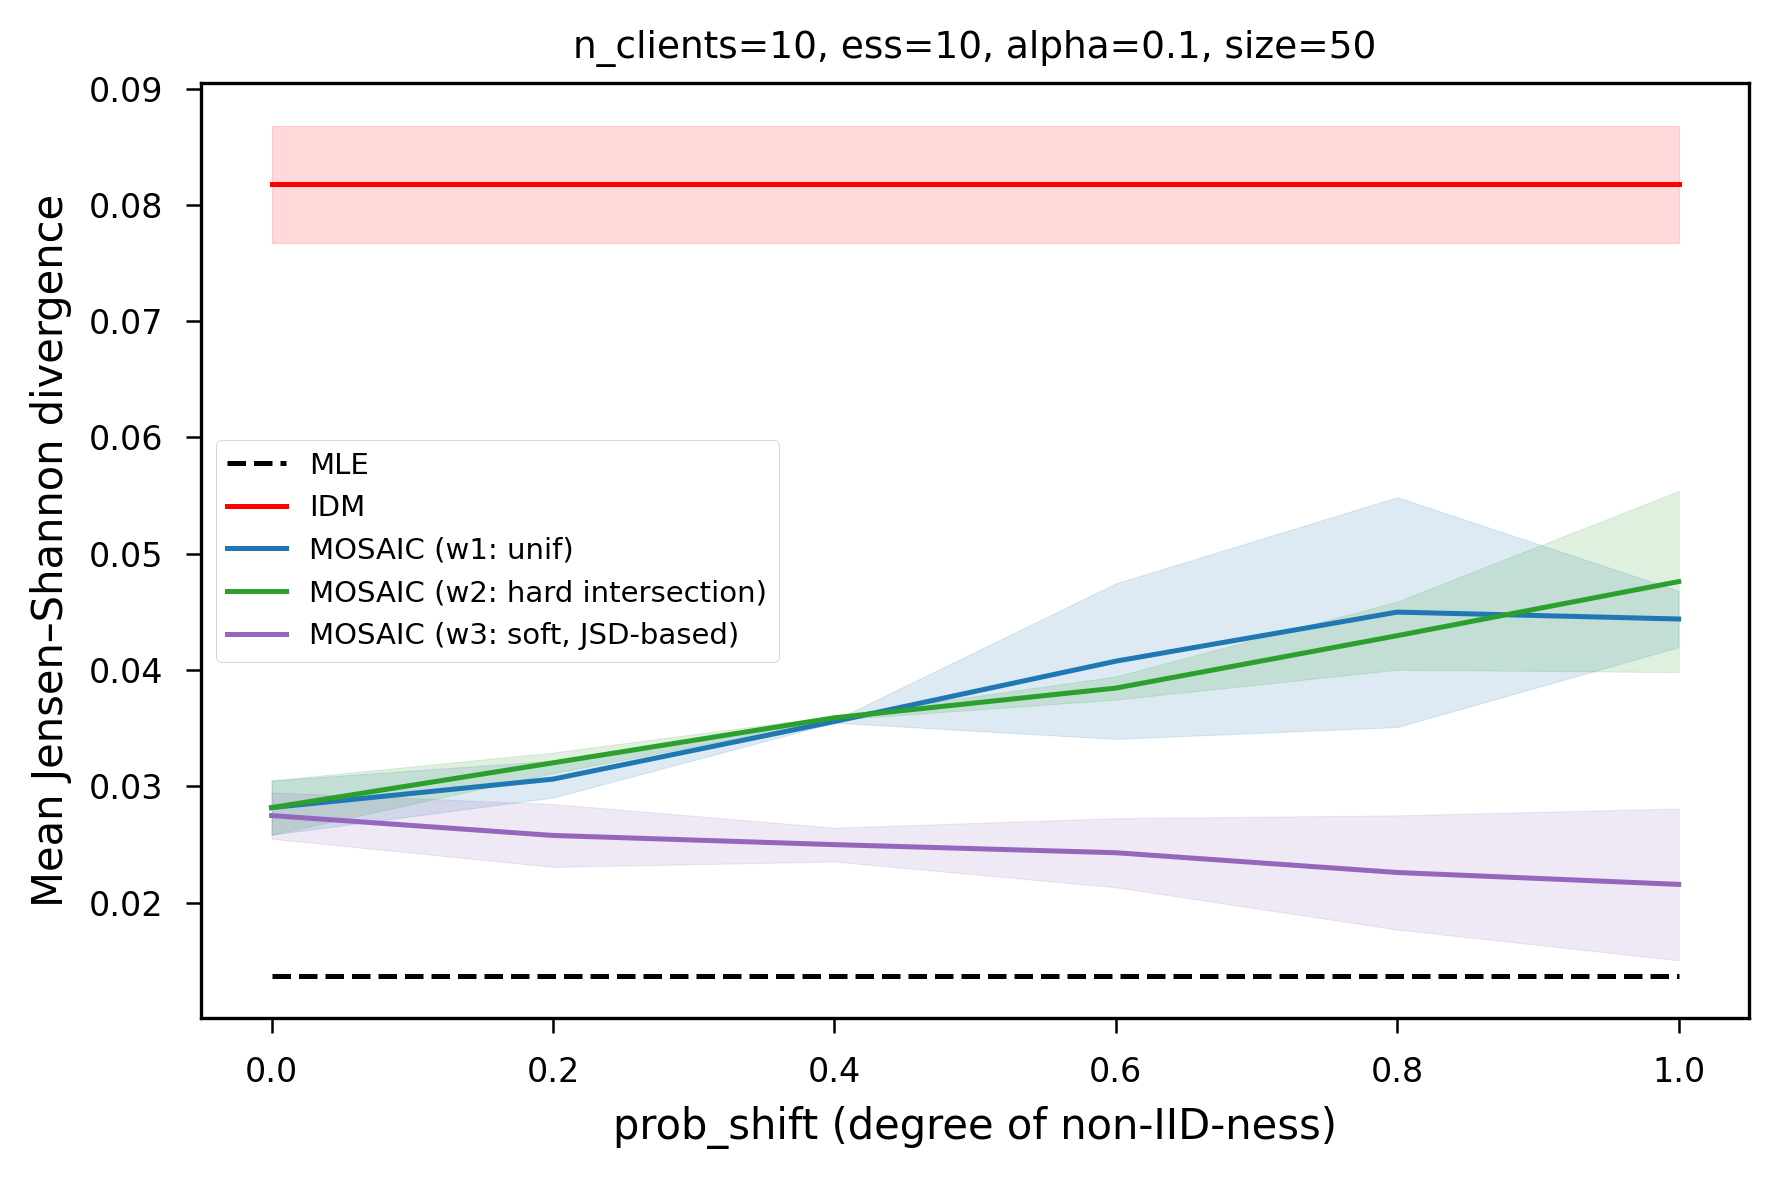

In [5]:
mos_colors = {1: "tab:blue", 2: "tab:green", 3: "tab:purple"}
mos_labels = {
    1: "MOSAIC (w1: unif)",
    2: "MOSAIC (w2: hard intersection)",
    3: "MOSAIC (w3: soft, JSD-based)",
}

fig, ax = plt.subplots()

ax.plot(df_g["prob_shift"], df_g["mle"], "--", color="black", label="MLE")

ax.fill_between(
    df_g["prob_shift"], df_g["idm_mean"] - df_g["idm_mean_std"],
    df_g["idm_mean"] + df_g["idm_mean_std"], color="red", alpha=.15,
)
ax.plot(df_g["prob_shift"], df_g["idm_mean"], color="red", label="IDM")

for w, color in mos_colors.items():
    m = df_g[f"mos_w{w}_mean"]
    s = df_g[f"mos_w{w}_mean_std"]
    ax.fill_between(df_g["prob_shift"], m - s, m + s, color=color, alpha=.15)
    ax.plot(df_g["prob_shift"], m, color=color, label=mos_labels[w])

ax.set_xlabel("prob_shift (degree of non-IID-ness)")
ax.set_ylabel("Mean Jensen–Shannon divergence")
ax.set_title(
    f"n_clients={fixed['n_clients']}, ess={fixed['ess']}, "
    f"alpha={fixed['alpha']}, size={fixed['size']}",
    fontsize=9,
)
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)